In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================
# 1. 讀取與清理資料
# =========================
df = pd.read_csv('NBA_Normalized_Final.csv')

bool_cols = ['Is_Undrafted', 'Pos_PG', 'Pos_C', 'Pos_SG', 'Pos_SF', 'Pos_PF']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
target_year=2023

# =========================
# 2. 篩選資料 (三年級 WS 預測)
# =========================
df_g = df[(df['season'] > 2)&(df['year_start']>1999)&(df['year_start']!=target_year) ].copy()

feature_cols = [
    '2P%','2PA','3P','3P%','3PA','3PAr','AST','AST%','BLK','BLK%','BPM','DBPM',
    'DRB','DRB%','DWS','FG','FG%','FGA','FT','FT%','FTA','FTr',
    'OBPM','ORB','ORB%','OWS','PER','PF','PTS','Pos_C','Pos_PF','Pos_PG',
    'Pos_SF','Pos_SG','STL','STL%','TOV','TOV%','TRB','TRB%','TS%','USG%',
    'VORP','WS','WS/48','eFG%'
]
target_col = 'Year4_WS'

# 清洗目標值與特徵值
data = df_g.dropna(subset=[target_col]).copy()
for c in feature_cols:
    data[c] = pd.to_numeric(data[c], errors='coerce')
data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
data = data.dropna(subset=[target_col]).copy()

X = data[feature_cols].copy()
y = data[target_col].copy()

# =========================
# 3. 切分訓練 / 測試 
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. 建立 Pipeline 與 GridSearchCV
# =========================

alphas = np.logspace(-4, 1, 40)
cv_splits = min(5, len(X_train))

# 建立管線
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=50000, random_state=42, tol=1e-4))
])

# 使用 GridSearchCV 來自動尋找最佳 alpha
param_grid = {'lasso__alpha': alphas}
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=cv_splits, 
    scoring='r2', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# =========================
# 5. 計算各項指標
# =========================
# 取出最佳模型
best_model = grid_search.best_estimator_
best_alpha = grid_search.best_params_['lasso__alpha']
best_cv_r2 = grid_search.best_score_

# 預測並計算 R2
train_r2 = r2_score(y_train, best_model.predict(X_train))
test_r2 = r2_score(y_test, best_model.predict(X_test))

# 計算 RMSE 與 MAE
y_pred_test = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

# 提取 Lasso 獨有的「特徵選擇」結果
lasso_coefs = best_model.named_steps["lasso"].coef_
n_total_features = len(feature_cols)
n_retained_features = np.sum(lasso_coefs != 0)

# =========================
# 6. 正式輸出實戰報告
# =========================
print("\n" + "="*45)
print("         LASSO REGRESSION FINAL REPORT")
print("="*45)
print(f"1. Train R² (訓練集得分):   {train_r2:.4f}")
print(f"2. Best CV R² (交叉驗證):  {best_cv_r2:.4f}")
print(f"3. Test R² (實測測試集):   {test_r2:.4f}")
print("-" * 45)
print(f"Chosen Alpha (最佳 λ):     {best_alpha:.4f}")
print(f"Test RMSE:                {rmse_test:.4f}")
print(f"Test MAE:                 {mae_test:.4f}")
print(f"Feature Selection:        保留 {n_retained_features} / {n_total_features} 個特徵")
print("="*45)

# =========================
# 7. 顯示被 Lasso 保留的關鍵特徵
# =========================
coef_df = pd.DataFrame({"feature": feature_cols, "coef": lasso_coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

# 只列出係數不為 0 的特徵
active_features = coef_df[coef_df["coef"] != 0].sort_values("abs_coef", ascending=False)

print(active_features[["feature", "coef"]].head(15).to_string(index=False))


         LASSO REGRESSION FINAL REPORT
1. Train R² (訓練集得分):   0.5127
2. Best CV R² (交叉驗證):  0.4826
3. Test R² (實測測試集):   0.4907
---------------------------------------------
Chosen Alpha (最佳 λ):     0.0661
Test RMSE:                1.9051
Test MAE:                 1.5315
Feature Selection:        保留 9 / 46 個特徵

📌 Lasso 認定最有價值的核心特徵 (排除係數為 0 的雜訊):
feature      coef
     WS  1.244829
   VORP  0.580766
 Pos_PF -0.094851
    DRB  0.075954
   TRB%  0.053139
    BLK  0.051469
    TOV  0.049444
     PF  0.046806
   DRB%  0.013502


In [90]:
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error

# -------------------------
# 1) 切 train/test
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# 2) 建立 Lasso（一定要標準化）
# -------------------------
lasso_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), # 💡 核心修正：填補空值
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        alpha=best_alpha,     # ⭐ 套你找好的最佳 alpha
        max_iter=100000,
        random_state=42
    ))
])

# -------------------------
# 3) 訓練
# -------------------------
lasso_model.fit(X_train, y_train)

# -------------------------
# 4) 預測
# -------------------------
y_train_pred = lasso_model.predict(X_train)
y_test_pred  = lasso_model.predict(X_test)

# -------------------------
# 5) 指標：RMSE / MAE / MedianAE
# -------------------------
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

mae_test   = mean_absolute_error(y_test, y_test_pred)
medae_test = median_absolute_error(y_test, y_test_pred)

# -------------------------
# 6) CV RMSE mean ± std
# -------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lasso_model,
    X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

cv_rmse = -cv_scores
cv_mean = cv_rmse.mean()
cv_std  = cv_rmse.std(ddof=1)

# -------------------------
# 7) Train–Test Gap
# -------------------------
gap = rmse_test - rmse_train

# -------------------------
# 8) Spearman rank correlation（test）
# -------------------------
def spearman_corr(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    def rankdata(a):
        order = np.argsort(a)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(a), dtype=float)
        _, inv, counts = np.unique(a, return_inverse=True, return_counts=True)
        sums = np.bincount(inv, ranks)
        avg = sums / counts
        return avg[inv]

    rt = rankdata(y_true)
    rp = rankdata(y_pred)
    rt = rt - rt.mean()
    rp = rp - rp.mean()
    denom = np.sqrt((rt**2).sum() * (rp**2).sum())
    return float((rt * rp).sum() / denom) if denom != 0 else np.nan

spearman = spearman_corr(y_test, y_test_pred)

# -------------------------
# 9) 輸出 6 個結果
# -------------------------
print(f"alpha: {best_alpha}")
print(f"RMSE (test): {rmse_test:.6f}")
print(f"MAE  (test): {mae_test:.6f}")
print(f"MedianAE (test): {medae_test:.6f}")
print(f"CV RMSE (train, 5-fold): {cv_mean:.6f} ± {cv_std:.6f}")
print(f"Train–Test Gap (RMSE_test - RMSE_train): {gap:.6f}")
print(f"Spearman rank corr (test): {spearman:.6f}")


===== Lasso Regression Evaluation =====
alpha: 0.06614740641230146
RMSE (test): 1.905060
MAE  (test): 1.531547
MedianAE (test): 1.245205
CV RMSE (train, 5-fold): 1.967809 ± 0.166767
Train–Test Gap (RMSE_test - RMSE_train): -0.034323
Spearman rank corr (test): 0.697190


In [91]:
#3
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# =========================
# 1. 讀取資料
# =========================
df_main = pd.read_csv("NBA_Normalized_Final.csv")

# TRUE/FALSE 欄位處理
bool_cols = ['Is_Undrafted']
for col in bool_cols:
    if col in df_main.columns:
        df_main[col] = (
            df_main[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .map({
                "TRUE": 1, "FALSE": 0,
                "1": 1, "0": 0,
                "1.0": 1, "0.0": 0
            })
        )

# dummy 欄位處理
dummy_cols = ['Pos_PG', 'Pos_C', 'Pos_SG', 'Pos_SF', 'Pos_PF']
for col in dummy_cols:
    if col in df_main.columns:
        df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

# 定義目標欄位
target_col = "Year3_WS"

# 訓練集
df_train = df_main[
    (df_main["year_start"] != target_year) & 
    (df_main["season"] > 1) &
    (df_main[target_col].notna())  # 💡 確保訓練集的人都有第三年成績
].copy()

# 預測集
df_2000 = df_main[
    (df_main["year_start"] == target_year) & 
    (df_main["season"] > 1) & 
    (df_main['DraftRank'] < 31)
].copy()

# =========================
# 2. 特徵欄位轉換
# =========================
feature_cols = [
    '2P%', '2PA', '3P', '3P%', '3PA', '3PAr', 'AST', 'AST%', 'BLK', 'BLK%',
    'BPM', 'DBPM', 'DRB', 'DRB%', 'DWS', 'DraftRank', 'FG', 'FG%', 'FGA',
    'FT', 'FT%', 'FTA', 'FTr', 'OBPM', 'ORB', 'ORB%', 'OWS', 'PER', 'PF',
    'PTS', 'Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG', 'STL', 'STL%',
    'TOV', 'TOV%', 'TRB', 'TRB%', 'TS%', 'USG%', 'VORP', 'WS', 'WS/48',
    'eFG%', 'Is_Undrafted'
]

# 全部轉數值並確保訓練標籤為數值
for col in feature_cols:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce')
    df_2000[col] = pd.to_numeric(df_2000[col], errors='coerce')

df_train[target_col] = pd.to_numeric(df_train[target_col], errors='coerce')

X_train = df_train[feature_cols]
y_train = df_train[target_col]
X_pred = df_2000[feature_cols] 

print(f"訓練樣本數 (有第三年成績)：{len(X_train)}")
print(f"預測樣本數 (2009梯次全體)：{len(X_pred)}")

# =========================
# 3. 訓練模型
# =========================
final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("Lasso", Lasso(alpha=best_alpha)) 
])

final_model.fit(X_train, y_train)

# =========================
# 4. 預測
# =========================
df_2000["Pred_WS"] = final_model.predict(X_pred).ravel()

# =========================
# 5. 經濟價值計算 
# =========================
try:
    eco_ref = df_main[df_main["year_start"] == target_year].iloc[0]
    SALARY_CAP_2000 = eco_ref['Salary_Cap_At_Start']
    BRI_FACTOR_2000 = eco_ref['BRI_Factor']
    TEAM_COUNT_2000 = 30 
    TOTAL_GAMES = 1230
    marginal_value_per_ws = (SALARY_CAP_2000 * TEAM_COUNT_2000 * BRI_FACTOR_2000) / TOTAL_GAMES
except:
    SALARY_CAP_2000 = 57.7
    marginal_value_per_ws = 2.5 

df_2000["Pred_Dollar_Value_M"] = df_2000["Pred_WS"] * marginal_value_per_ws
df_2000["Pred_Salary_Share_Percent"] = (df_2000["Pred_Dollar_Value_M"] / SALARY_CAP_2000) * 100

def get_cost_percent(row):
    rank = row["DraftRank"]
    if 1 <= rank <= 30:
        return 8.0 - (rank - 1) * (6.5 / 29)
    return 1.1

df_2000["Est_Cost_Percent"] = df_2000.apply(get_cost_percent, axis=1)
df_2000["Pred_ROI"] = df_2000["Pred_Salary_Share_Percent"] / df_2000["Est_Cost_Percent"]
df_2000["Net_Surplus_Percent"] = df_2000["Pred_Salary_Share_Percent"] - df_2000["Est_Cost_Percent"]

# =========================
# 6. 結果 
# =========================
result = df_2000[[
    "Player", "DraftRank", "Pred_WS", "Year4_WS", 
    "Pred_Salary_Share_Percent", "Est_Cost_Percent", "Pred_ROI","Net_Surplus_Percent"
]].sort_values("Pred_WS", ascending=False)


print(result)

訓練樣本數 (有第三年成績)：2007
預測樣本數 (2009梯次全體)：29
=== 2009年球員經濟價值預測（包含第三年未出賽球員） ===
                   Player  DraftRank   Pred_WS  Year4_WS  \
3247       Jalen Williams         12  6.940700       3.0   
3228       Paolo Banchero          1  5.896919       5.0   
3237       Walker Kessler         22  5.777820       0.5   
3232          Jalen Duren         13  4.929594      11.0   
3260        Keegan Murray          4  4.836309       0.2   
3244     Jabari Smith Jr.          3  4.045794       6.6   
3248        Mark Williams         15  3.264744       6.3   
3229      Christian Braun         21  2.862248       3.0   
3230        Dyson Daniels          8  2.710892       6.6   
3240   Bennedict Mathurin          6  2.692981       1.4   
3233           Tari Eason         17  2.645441       2.9   
3246        Peyton Watson         30  1.956883       2.6   
3270         Nikola Jović         27  1.903781       0.0   
3243       Shaedon Sharpe          7  1.801839       1.3   
3236           Jaden Ivey 

C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


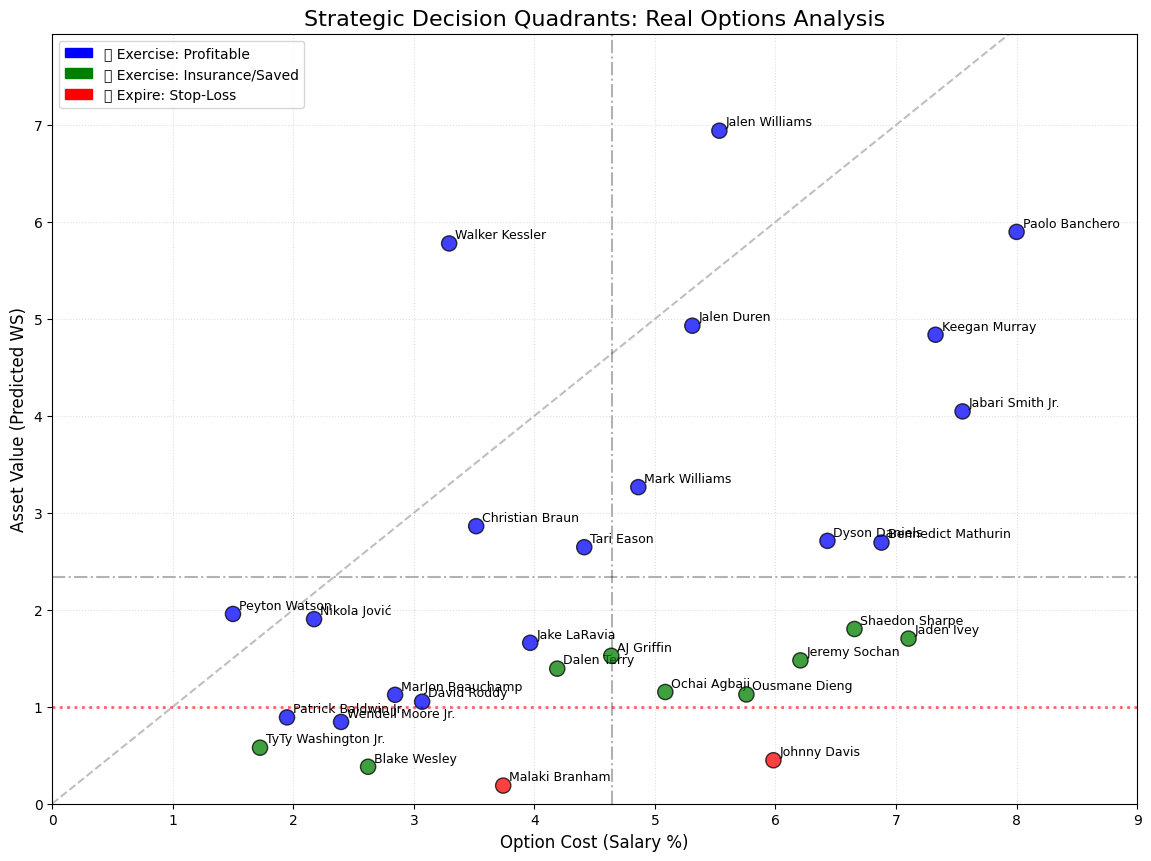


             NBA CONTRACT OPTION STRATEGY REPORT
總分析球員數: 29
🔵 建議執行 (獲利區): 18 名
🟢 建議執行 (保險區): 9 名
🔴 建議放棄 (止損區): 2 名
------------------------------------------------------------

💡 [表現救贖] 以下球員雖經濟小虧，但因 WS > 1.0 建議保留：
       Player  Pred_WS  Net_Surplus_Percent
   Jaden Ivey 1.702851            -2.119494
Ousmane Dieng 1.126947            -2.460240

!!!!!!!!!!!!!!!!!!!! 🛑 CRITICAL STOP-LOSS LIST (RED ZONE) !!!!!!!!!!!!!!!!!!!!
以下球員預測價值嚴重低於合約成本，且戰力未達標，強烈建議不執行期權：
---------------------------------------------------------------------------
        Player  DraftRank  Pred_WS  Net_Surplus_Percent
  Johnny Davis         10 0.448429            -4.670284
Malaki Branham         20 0.186837            -3.194540
---------------------------------------------------------------------------

報告結束。請根據團隊薪資空間 (Cap Space) 彈性調整決策。


In [92]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ==========================================
# 1. 準備數據與顏色 
# ==========================================
rmse_threshold = rmse_test  
ws_ceiling = 1.0            

# 判定邏輯
cond_red = (df_2000["Net_Surplus_Percent"] < -rmse_threshold) & (df_2000["Pred_WS"] < ws_ceiling)
cond_blue = (df_2000["Net_Surplus_Percent"] > 0)
cond_green_orig = (df_2000["Net_Surplus_Percent"] <= 0) & (df_2000["Net_Surplus_Percent"] >= -rmse_threshold)
cond_green_save = (df_2000["Net_Surplus_Percent"] < -rmse_threshold) & (df_2000["Pred_WS"] >= ws_ceiling)

conditions = [cond_red, cond_blue, (cond_green_orig | cond_green_save)]
choices = ["red", "blue", "green"]
df_2000["plot_color"] = np.select(conditions, choices, default="gray")

# ==========================================
# 2. 繪圖
# ==========================================
plt.figure(figsize=(14, 10))

x = df_2000["Est_Cost_Percent"]
y = df_2000["Pred_WS"]

# 散點圖
plt.scatter(x, y, c=df_2000["plot_color"], s=120, alpha=0.75, edgecolors="black", linewidth=1, zorder=5)



# 1. 損益兩平線 (Diagonal Line: y = x) 
lims = [0, max(x.max(), y.max()) + 1]
plt.plot(lims, lims, color="gray", linestyle="--", alpha=0.5, label="Break-even (Value = Cost)", zorder=1)

# 2. 表現及格線 (Horizontal Line)
plt.axhline(ws_ceiling, color="red", linestyle=":", linewidth=2, alpha=0.6, label=f"WS Ceiling ({ws_ceiling})", zorder=2)

# 3. 平均成本線 (Vertical Line)
plt.axvline(x.mean(), color="black", linestyle="-.", alpha=0.3, label=f"Avg Cost ({x.mean():.2f}%)", zorder=1)

# 4. 平均表現線 (Horizontal Line)
plt.axhline(y.mean(), color="black", linestyle="-.", alpha=0.3, label=f"Avg WS ({y.mean():.2f})", zorder=1)


for i, row in df_2000.iterrows():
    plt.text(row["Est_Cost_Percent"] + 0.05, row["Pred_WS"] + 0.05, row["Player"], fontsize=9)

plt.xlabel("Option Cost (Salary %)", fontsize=12)
plt.ylabel("Asset Value (Predicted WS)", fontsize=12)
plt.title("Strategic Decision Quadrants: Real Options Analysis", fontsize=16)

# 圖例
blue_patch = mpatches.Patch(color='blue', label='🔵 Exercise: Profitable')
green_patch = mpatches.Patch(color='green', label='🟢 Exercise: Insurance/Saved')
red_patch = mpatches.Patch(color='red', label='🔴 Expire: Stop-Loss')
plt.legend(handles=[blue_patch, green_patch, red_patch], loc='upper left')

plt.grid(True, linestyle=':', alpha=0.4)
plt.xlim(0, x.max() + 1)
plt.ylim(0, y.max() + 1)
plt.show()
# ==========================================
# 5. 決策報告
# ==========================================

print("\n" + "="*60)
print("NBA CONTRACT OPTION STRATEGY REPORT")
print("="*60)


total_players = len(df_2000)
red_count = len(df_2000[df_2000["plot_color"] == "red"])
blue_count = len(df_2000[df_2000["plot_color"] == "blue"])
green_count = len(df_2000[df_2000["plot_color"] == "green"])

print(f"總分析球員數: {total_players}")
print(f"🔵 建議執行 (獲利區): {blue_count} 名")
print(f"🟢 建議執行 (保險區): {green_count} 名")
print(f"🔴 建議放棄 (止損區): {red_count} 名")
print("-" * 60)


saved_players = df_2000[(df_2000["plot_color"] == "green") & (df_2000["Net_Surplus_Percent"] < -rmse_threshold)]
if not saved_players.empty:
    print(f"\n💡 [表現救贖] 以下球員雖經濟小虧，但因 WS > {ws_ceiling} 建議保留：")
    print(saved_players[["Player", "Pred_WS", "Net_Surplus_Percent"]].sort_values("Pred_WS", ascending=False).to_string(index=False))


print("\n" + "!"*20 + " 🛑 CRITICAL STOP-LOSS LIST (RED ZONE) " + "!"*20)
red_zone = df_2000[df_2000["plot_color"] == "red"].copy()

if red_zone.empty:
    print("無絕對止損球員")
else:

    red_zone_sorted = red_zone[["Player", "DraftRank", "Pred_WS", "Net_Surplus_Percent"]].sort_values("Net_Surplus_Percent")
    
    print("以下球員強烈建議不執行：")
    print("-" * 75)
    print(red_zone_sorted.to_string(index=False))
    print("-" * 75)
